In [ ]:
from databricks.connect import DatabricksSession

# Create the spark session
spark = DatabricksSession.builder.serverless().getOrCreate()

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

plt.style.use('dark_background')

### Understand how the severity of a country impacts the funding they receive for different clusters 

In [44]:
funding_country_cluster_df = pd.read_csv('Humanitarian_Response_Coverage_Analysis_2024_2026.csv')
all_crises_df = pd.read_csv('all_crises.csv')

# Restrict to 2025
funding_country_cluster_df = funding_country_cluster_df[funding_country_cluster_df['year'] == 2025]
all_crises_df['year'] = all_crises_df['period'].str.extract(r'(\d{4})').astype(int)
all_crises_df = all_crises_df[all_crises_df['year'] == 2025]

In [45]:
# Combine the crises to obtain a per country per year severity level

severity_cols = [
    'Impact of the crisis', 'Geographical Impact', "Human Impact",'Conditions of affected people', 'People in need',
    'Concentration of conditions', 'Complexity', 'Society and safety',
    'Operating environment'
]

crises = all_crises_df.copy()

# Parse iso3 from string-list like "['AFG']" → 'AFG'
def parse_iso3(val):
    try:
        lst = ast.literal_eval(val)
        # return a new row for each iso3 in the list, or np.nan if the list is empty
        return lst if lst else np.nan
    except Exception:
        return np.nan
    
crises['iso3'] = crises['iso3'].apply(parse_iso3)
crises = crises.explode('iso3', ignore_index=True)

crises['year'] = crises['period'].str.extract(r'(\d{4})').astype(int)

avg_crisis_by_country_year = (
    crises.groupby(['iso3', 'year', 'crisis_id'])
    .agg(
        mean_severity=('INFORM Severity Index', 'mean'),
        max_severity=('INFORM Severity Index', 'max'),
        **{col.replace(' ', '_').lower(): (col, 'mean') for col in severity_cols}
    )
    .reset_index()
)

def exponential_adding(vals):
    return np.log(np.sum(np.exp(vals)) + 1e-9)  # Add a small constant to prevent log(0)

crisis_by_country_year = (
    avg_crisis_by_country_year.groupby(['iso3', 'year'])
    .agg(
        total_severity=('mean_severity', exponential_adding),
        max_severity=('max_severity', 'max'),
        **{col: (col, exponential_adding) for col in [i.replace(' ', '_').lower() for i in severity_cols]}
    )
    .reset_index()
)

# crisis_by_country_year['severity_quartile'] = pd.qcut(crisis_by_country_year['total_severity'], q=4, labels=False)

In [46]:
# Merge the two dataframes on 'iso3' for crisis_by_country_year and 'country_code' for funding_country_cluster_df
merged_df = pd.merge(
    funding_country_cluster_df,
    crisis_by_country_year,
    left_on=['country_code', 'year'],
    right_on=['iso3', 'year'],
    how='left'
)
merged_df['severity_quartile'] = pd.qcut(merged_df['total_severity'], q=4, labels=False)

In [47]:
merged_df.groupby('severity_quartile').agg(
    avg_funding=('percent_funded', 'mean'),
    avg_percent_targeted=('percent_targeted', 'mean')
).reset_index()

,severity_quartile,avg_funding,avg_percent_targeted
0,0,63.377174,41.451282
1,1,35.990196,54.858730
2,2,48.351485,47.623188
3,3,38.438318,47.265517


In [48]:
funding_country_cluster_df.cluster.value_counts()

cluster
Health                                        33
Not specified                                 33
Multiple clusters/sectors (shared)            33
Food Security                                 33
Water Sanitation Hygiene                      33
Education                                     33
Protection                                    32
Nutrition                                     32
Coordination and support services             31
Protection - Child Protection                 31
Emergency Shelter and NFI                     30
Protection - Gender-Based Violence            30
Multi-sector                                  25
Multipurpose Cash                             24
Early Recovery                                23
Other                                         22
Logistics                                     22
Camp Coordination / Management                20
Protection - Mine Action                      16
Agriculture                                   14
Protection -

---
## Analysis 1 — Proportionality Approach
**Question:** Do crises with the highest severity receive a higher share of their required funding?

Coverage Ratio = Funding Received / Funding Required. If the global system is fair, this should be highest for the most severe crises.

C:\Users\Asus\AppData\Local\Temp\ipykernel_19624\2695302245.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(


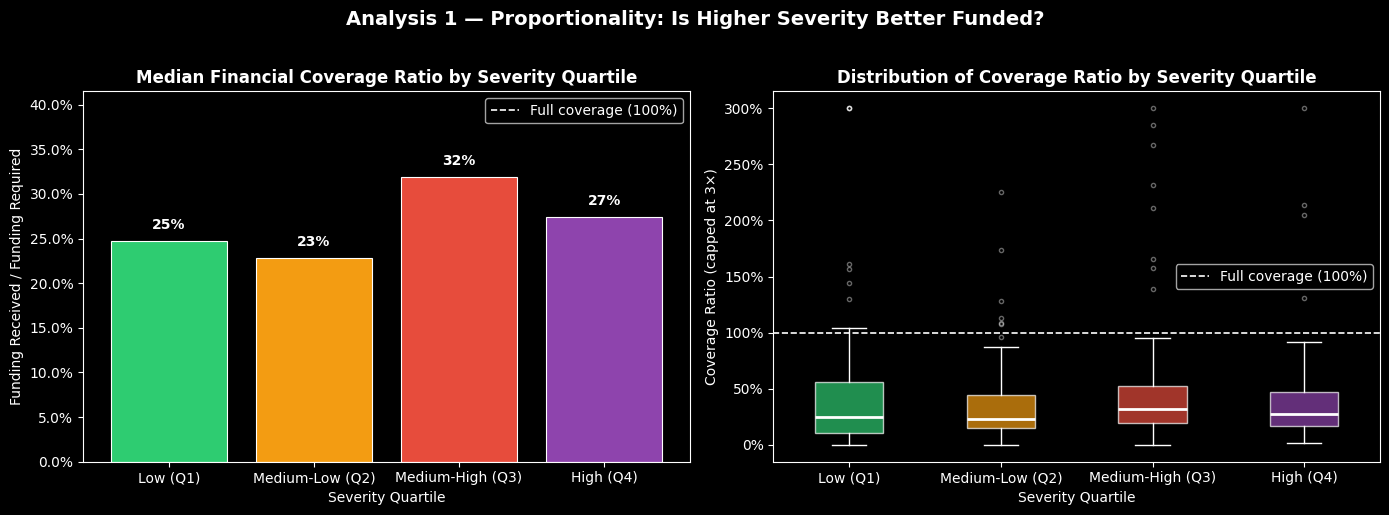

Severity Quartile  Median Coverage Ratio  Mean Coverage Ratio  N Clusters
         Low (Q1)               0.247837             0.474275          92
  Medium-Low (Q2)               0.228279             0.359854         102
 Medium-High (Q3)               0.319242             0.477790         101
        High (Q4)               0.273978             0.383939         107


In [49]:
# ── Analysis 1: Proportionality Approach ──────────────────────────────────────

a1 = merged_df.dropna(subset=['requirements', 'funding', 'severity_quartile']).copy()
a1 = a1[(a1['requirements'] > 0) & (a1['funding'] >= 0)]

# Coverage ratio — cap at 3× to prevent extreme over-funded outliers from distorting the view
a1['coverage_ratio'] = (a1['funding'] / a1['requirements']).clip(upper=3.0)

quartile_labels = {0: 'Low (Q1)', 1: 'Medium-Low (Q2)', 2: 'Medium-High (Q3)', 3: 'High (Q4)'}
a1['severity_label'] = a1['severity_quartile'].map(quartile_labels)

stats_a1 = (
    a1.groupby('severity_label')['coverage_ratio']
    .agg(['median', 'mean', 'count'])
    .reindex(quartile_labels.values())
    .reset_index()
    .rename(columns={
        'severity_label': 'Severity Quartile',
        'median': 'Median Coverage Ratio',
        'mean': 'Mean Coverage Ratio',
        'count': 'N Clusters'
    })
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
order = list(quartile_labels.values())

# Bar chart — median coverage by severity
bars = axes[0].bar(
    stats_a1['Severity Quartile'], stats_a1['Median Coverage Ratio'],
    color=colors, edgecolor='white', linewidth=0.8
)
axes[0].axhline(y=1.0, color='white', linestyle='--', linewidth=1.2, label='Full coverage (100%)')
for bar, val in zip(bars, stats_a1['Median Coverage Ratio']):
    if not np.isnan(val):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f'{val:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold'
        )
axes[0].set_title('Median Financial Coverage Ratio by Severity Quartile', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Severity Quartile')
axes[0].set_ylabel('Funding Received / Funding Required')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].legend()
axes[0].set_ylim(0, stats_a1['Median Coverage Ratio'].fillna(0).max() * 1.3)

# Box plot — full distribution by severity
data_by_quartile = [a1[a1['severity_label'] == lbl]['coverage_ratio'].values for lbl in order]
bp = axes[1].boxplot(
    data_by_quartile, labels=order, patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(y=1.0, color='white', linestyle='--', linewidth=1.2, label='Full coverage (100%)')
axes[1].set_title('Distribution of Coverage Ratio by Severity Quartile', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Severity Quartile')
axes[1].set_ylabel('Coverage Ratio (capped at 3×)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend()

plt.suptitle('Analysis 1 — Proportionality: Is Higher Severity Better Funded?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(stats_a1.to_string(index=False))

---
## Analysis 2 — Per Capita Approach
**Question:** For crises of equal severity, how much money does each targeted person actually receive?

Funding requirements are subjective estimates — looking at USD per person targeted bypasses that and exposes geographic inequity in how human lives are valued by donors.

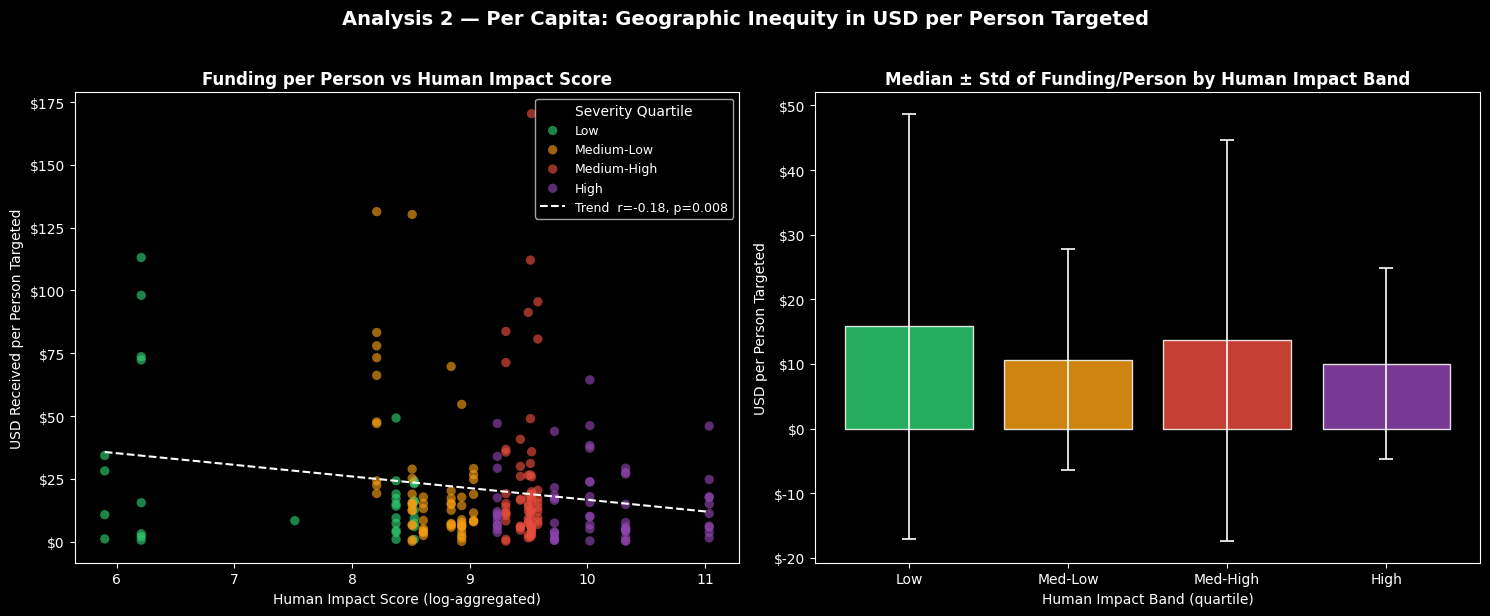


Funding per person by impact band:
impact_band    median       std  count
        Low 15.810927 32.911149     57
    Med-Low 10.679409 17.130376     64
   Med-High 13.627932 31.086350     55
       High  9.997493 14.784546     48

── Highest funded per person (Q3/Q4 severity) ──
country_code                  cluster  severity_quartile  funding_per_person
         YEM             Multi-sector                  2          170.344028
         TCD             Multi-sector                  2          112.071110
         COL Protection - Mine Action                  2           95.478204
         AFG                Education                  2           91.223298
         SSD            Food Security                  2           83.688809

── Lowest funded per person (Q3/Q4 severity) ──
country_code                                 cluster  severity_quartile  funding_per_person
         SSD Protection - Housing, Land and Property                  2            0.167476
         NGA          Ca

In [51]:
# ── Analysis 2: Per Capita Approach ────────────────────────────────────────────

a2 = merged_df.dropna(subset=['funding', 'targeted', 'human_impact', 'severity_quartile']).copy()
a2 = a2[(a2['targeted'] > 0) & (a2['funding'] > 0)]
a2['funding_per_person'] = a2['funding'] / a2['targeted']

# Cap at 99th percentile for cleaner scatter (extreme outliers compress the view)
cap = a2['funding_per_person'].quantile(0.99)
a2_plot = a2[a2['funding_per_person'] <= cap].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette    = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c', 3: '#8e44ad'}
q_labels   = {0: 'Low', 1: 'Medium-Low', 2: 'Medium-High', 3: 'High'}

# Scatter: $/person vs Human Impact, coloured by severity quartile
for q, grp in a2_plot.groupby('severity_quartile'):
    axes[0].scatter(
        grp['human_impact'], grp['funding_per_person'],
        label=q_labels[q], color=palette[q], alpha=0.65, s=45, edgecolors='none'
    )

slope, intercept, r, p, _ = stats.linregress(a2_plot['human_impact'], a2_plot['funding_per_person'])
x_range = np.linspace(a2_plot['human_impact'].min(), a2_plot['human_impact'].max(), 200)
axes[0].plot(x_range, slope * x_range + intercept, 'w--', linewidth=1.5,
             label=f'Trend  r={r:.2f}, p={p:.3f}')

axes[0].set_title('Funding per Person vs Human Impact Score', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Human Impact Score (log-aggregated)')
axes[0].set_ylabel('USD Received per Person Targeted')
axes[0].legend(title='Severity Quartile', fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Bar chart: median ± std by human-impact band
a2_plot = a2_plot.copy()
a2_plot['impact_band'] = pd.qcut(a2_plot['human_impact'], q=4,
                                  labels=['Low', 'Med-Low', 'Med-High', 'High'])
band_stats = (
    a2_plot.groupby('impact_band', observed=True)['funding_per_person']
    .agg(['median', 'std', 'count'])
    .reset_index()
)

axes[1].bar(
    band_stats['impact_band'].astype(str), band_stats['median'],
    yerr=band_stats['std'], color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'],
    capsize=5, alpha=0.85, edgecolor='white',
    error_kw={'ecolor': 'white', 'elinewidth': 1.2, 'capthick': 1.2}
)
axes[1].set_title('Median ± Std of Funding/Person by Human Impact Band', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Human Impact Band (quartile)')
axes[1].set_ylabel('USD per Person Targeted')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Analysis 2 — Per Capita: Geographic Inequity in USD per Person Targeted',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nFunding per person by impact band:")
print(band_stats.to_string(index=False))

# Extreme inequity: same high-severity quartile, very different $/person
high_sev = a2_plot[a2_plot['severity_quartile'] >= 2]
print("\n── Highest funded per person (Q3/Q4 severity) ──")
print(high_sev.nlargest(5, 'funding_per_person')[
    ['country_code', 'cluster', 'severity_quartile', 'funding_per_person']
].to_string(index=False))

print("\n── Lowest funded per person (Q3/Q4 severity) ──")
print(high_sev.nsmallest(5, 'funding_per_person')[
    ['country_code', 'cluster', 'severity_quartile', 'funding_per_person']
].to_string(index=False))

---
## Analysis 3 — Regression & Residual Analysis
**Question:** Controlling for all measurable need factors simultaneously, which countries receive significantly more or less funding than their situation mathematically deserves?

A multiple linear regression (log-log scale) predicts "fair" funding from severity, human impact, people targeted, and requirements. The residuals reveal which countries are **forgotten crises** (under-funded).

Model R² = 0.489  (on 230 country-cluster observations)

Standardised coefficients (effect size per 1-SD change in predictor):
  total_severity              : +0.114
  human_impact                : -0.049
  log_targeted                : -0.090
  log_requirements            : +1.785


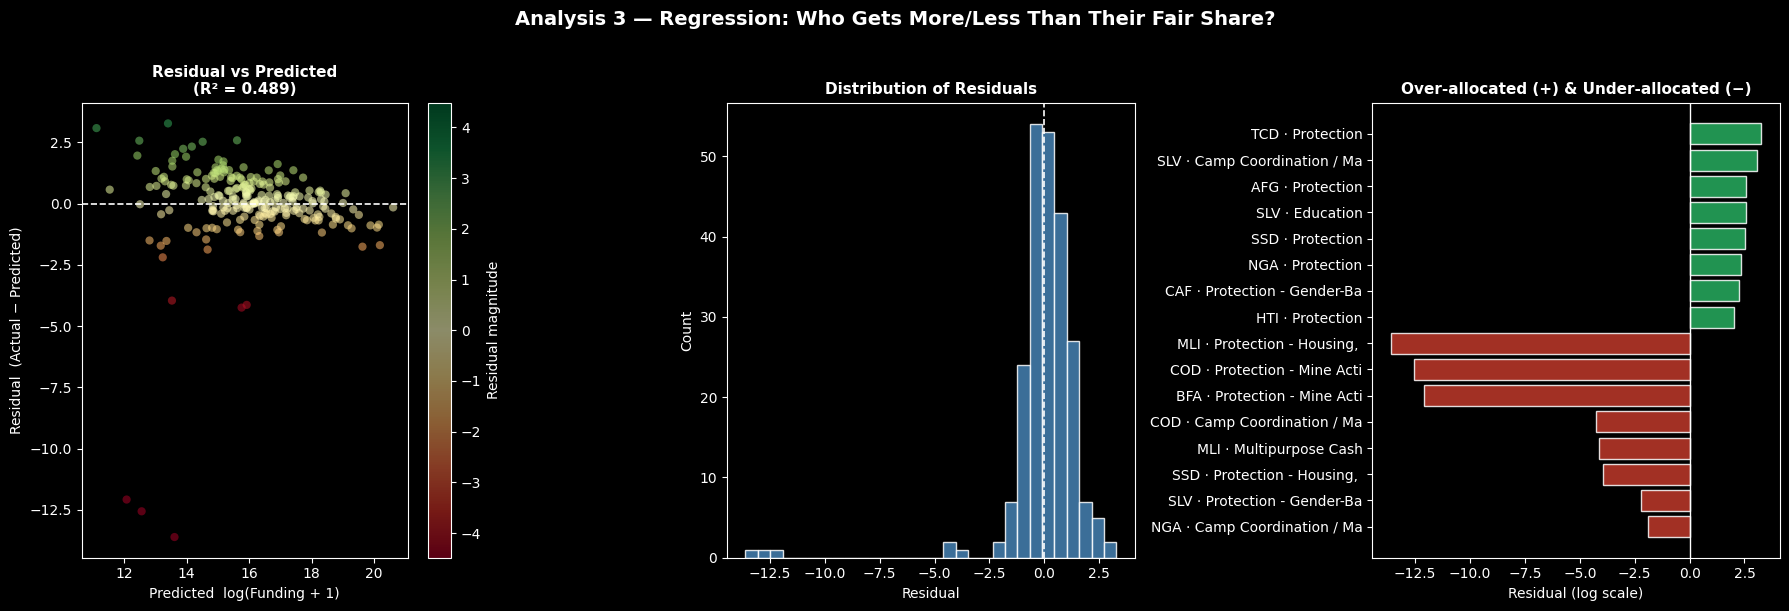


🟢  TOP OVER-ALLOCATION RELATIVE TO SEVERITY AND NEED
country_code                                 cluster    funding  requirements  total_severity  residual
         TCD                              Protection 17505756.0     6141970.0        9.324511  3.272479
         SLV          Camp Coordination / Management  1468699.0     1130000.0        5.933333  3.081345
         AFG                              Protection 79855072.0    37833707.0        9.048981  2.582139
         SLV                               Education  3456911.0     3332338.0        5.933333  2.567752
         SSD                              Protection 25101159.0    15135848.0        9.058302  2.523963
         NGA                              Protection 14590671.0    11164685.0       10.013170  2.327135
         CAF      Protection - Gender-Based Violence 10103158.0     9855993.0        7.858333  2.236407
         HTI                              Protection  6231780.0     7200000.0        8.675000  2.016644
         B

In [62]:
# ── Analysis 3: Regression & Residual Analysis ─────────────────────────────────

a3 = merged_df.dropna(subset=['total_severity', 'human_impact', 'targeted', 'requirements', 'funding']).copy()
a3 = a3[(a3['requirements'] > 0) & (a3['targeted'] > 0) & (a3['funding'] >= 0)]

# Log-transform skewed monetary / count variables; severity cols are already log-aggregated
a3['log_funding']      = np.log1p(a3['funding'])
a3['log_requirements'] = np.log1p(a3['requirements'])
a3['log_targeted']     = np.log1p(a3['targeted'])

feature_names = ['total_severity', 'human_impact', 'log_targeted', 'log_requirements']
X_raw = a3[feature_names].values
y     = a3['log_funding'].values

# Standardise features (zero mean, unit variance)
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
X_scaled = (X_raw - X_mean) / X_std

# OLS via numpy
X_int = np.column_stack([np.ones(len(X_scaled)), X_scaled])
coef, *_ = np.linalg.lstsq(X_int, y, rcond=None)
intercept, betas = coef[0], coef[1:]

y_pred    = X_int @ coef
residuals = y - y_pred
r2 = 1 - np.sum(residuals**2) / np.sum((y - y.mean())**2)

a3 = a3.copy()
a3['predicted_log_funding'] = y_pred
a3['residual']              = residuals

print(f"Model R² = {r2:.3f}  (on {len(a3)} country-cluster observations)")
print("\nStandardised coefficients (effect size per 1-SD change in predictor):")
for name, beta in zip(feature_names, betas):
    print(f"  {name:28s}: {beta:+.3f}")

# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Residual vs Predicted
std_r = residuals.std()
sc = axes[0].scatter(
    y_pred, residuals, alpha=0.55, s=35,
    c=residuals, cmap='RdYlGn', vmin=-2.5*std_r, vmax=2.5*std_r, edgecolors='none'
)
axes[0].axhline(0, color='white', linestyle='--', linewidth=1.2)
axes[0].set_xlabel('Predicted  log(Funding + 1)')
axes[0].set_ylabel('Residual  (Actual − Predicted)')
axes[0].set_title(f'Residual vs Predicted\n(R² = {r2:.3f})', fontsize=11, fontweight='bold')
plt.colorbar(sc, ax=axes[0], label='Residual magnitude')

# 2) Residual histogram
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='white', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals', fontsize=11, fontweight='bold')

# 3) Horizontal bar: top donor darlings & forgotten crises
n_show = 8
top_pos = a3.nlargest(n_show, 'residual')[['country_code', 'cluster', 'residual']].copy()
top_neg = a3.nsmallest(n_show, 'residual')[['country_code', 'cluster', 'residual']].copy()
extremes = pd.concat([top_pos, top_neg]).reset_index(drop=True)
extremes['label'] = extremes['country_code'] + ' · ' + extremes['cluster'].str[:22]
bar_colors = ['#27ae60' if r > 0 else '#c0392b' for r in extremes['residual']]

axes[2].barh(extremes['label'], extremes['residual'], color=bar_colors, alpha=0.85, edgecolor='white')
axes[2].axvline(0, color='white', linewidth=1)
axes[2].set_xlabel('Residual (log scale)')
axes[2].set_title('Over-allocated (+) & Under-allocated (−)', fontsize=11, fontweight='bold')
axes[2].invert_yaxis()

plt.suptitle('Analysis 3 — Regression: Who Gets More/Less Than Their Fair Share?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Summary tables ─────────────────────────────────────────────────────────────
cols = ['country_code', 'cluster', 'funding', 'requirements', 'total_severity', 'residual']

print("\n🟢  TOP OVER-ALLOCATION RELATIVE TO SEVERITY AND NEED")
print(a3.nlargest(10, 'residual')[cols].to_string(index=False))

print("\n🔴  TOP UNDER-ALLOCATIONS RELATIVE TO SEVERITY AND NEED")
print(a3.nsmallest(10, 'residual')[cols].to_string(index=False))

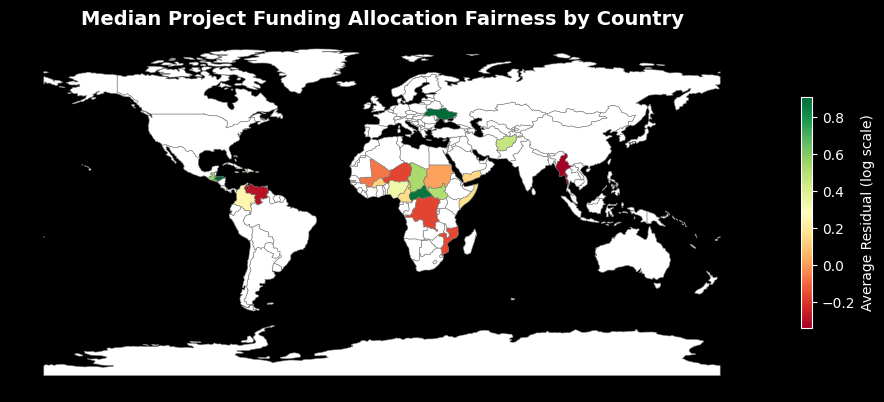

In [68]:
# Plot the severity of the residuals on a world map (requires geopandas and a world shapefile with iso3 codes)
import geopandas as gpd

# GeoPandas >= 1.0 removed gpd.datasets.get_path('naturalearth_lowres')
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# Normalize ISO3 column name to match the next line in your cell
if 'iso_a3' not in world.columns:
    if 'ISO_A3' in world.columns:
        world = world.rename(columns={'ISO_A3': 'iso_a3'})
    elif 'ADM0_A3' in world.columns:
        world = world.rename(columns={'ADM0_A3': 'iso_a3'})
world = world.rename(columns={'iso_a3': 'iso3'})
world = world.merge(
    a3.groupby('iso3')['residual'].median().reset_index(),
    left_on='iso3', right_on='iso3', how='left'
)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

world.plot(
    column='residual',
    cmap='RdYlGn',
    legend=True,
    ax=ax,
    edgecolor='grey',
    linewidth=0.4,
    legend_kwds={'label': "Average Residual (log scale)", 'shrink': 0.5},
    missing_kwds={'color': "#FFFFFF"}
)

ax.set_title('Median Project Funding Allocation Fairness by Country',
             fontsize=14, fontweight='bold', color='white')
ax.set_axis_off()
plt.show()